In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix
from sklearn.calibration import calibration_curve

champion = joblib.load("../models/champion_lgbm.pkl")

preprocessor = champion['preprocessor']
base_model = champion['base_model']
calibrator = champion['calibrator']
threshold = champion['best_threshold']

print(f"Champion threshold: {threshold:.4f}")
print(f"\nValidation metrics (2016):")
for k, v in champion['val_metrics'].items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Champion threshold: 0.1592

Validation metrics (2016):
  auc_uncalibrated: 0.7300
  auc_calibrated: 0.7298
  brier_uncalibrated: 0.1580
  brier_calibrated: 0.1572
  optimal_threshold: 0.1592
  optimal_profit_val_eval: 33321825.0000


In [2]:
df = pd.read_parquet("../data/loans_clean.parquet")

df['dti'] = df['dti'].replace([-1, 999], np.nan).clip(upper=100)
df['credit_history_months'] = df['credit_history_months'].replace(999, np.nan)
df['annual_inc'] = df['annual_inc'].clip(upper=1_000_000)
df['revol_util'] = df['revol_util'].clip(upper=100)

test_df = df[df['issue_year'] == 2017].copy()
y_test = test_df['default'].values

def prep_features(df):
    df = df.copy()
    
    redundant = [
        "fico_range_high",
        "funded_amnt",
        "funded_amnt_inv",
        "num_sats",
        "installment",
        "num_rev_tl_bal_gt_0",
    ]

    joint_cols = [c for c in df.columns if c.startswith("sec_app") or c.endswith("_joint")]

    high_cardinality = ["zip_code", "sub_grade"]

    split_cols = ["issue_year"]

    emp_map = {
        "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
        "5 years": 5, "6 years": 6, '7 years': 7, "8 years": 8, "9 years": 9,
        "10+ years": 10
    }
    df["emp_length"] = df["emp_length"].map(emp_map)
    
    cols_to_drop = redundant + joint_cols + high_cardinality + split_cols
    
    df = df.drop(
        columns=[c for c in cols_to_drop if c in df.columns]
    )
    
    return df

test_df_fe = prep_features(test_df)
x_test = test_df_fe.drop(columns=['default'])
x_test['term'] = x_test['term'].str.extract(r'(\d+)').astype(int)

loan_amounts_test = x_test['loan_amnt'].values

print("Feature dtype counts:")
print(x_test.dtypes.value_counts())

print("\nTest set 2017:")
print(f"  Loans: {len(test_df):,}")
print(f"  Actual default rate: {y_test.mean():.4f}")
print(f"  Input features: {x_test.shape[1]}")
print(f"  Total loan volume: ${loan_amounts_test.sum()/1e6:.1f}M")

Feature dtype counts:
float64    70
object      7
int64       1
Int64       1
Name: count, dtype: int64

Test set 2017:
  Loans: 169,300
  Actual default rate: 0.2312
  Input features: 79
  Total loan volume: $2421.2M


In [3]:
x_test_processed = preprocessor.transform(x_test)
raw_probs = base_model.predict_proba(x_test_processed)[:, 1]
calibrated_probs = calibrator.predict(raw_probs)
decisions_reject = (calibrated_probs >= threshold).astype(int)

print("Distribution of calibrated probabilities:")
print(f"  Mean: {calibrated_probs.mean():.4f}")
print(f"  Median: {np.median(calibrated_probs):.4f}")
print(f"  P10: {np.percentile(calibrated_probs, 10):.4f}")
print(f"  P90: {np.percentile(calibrated_probs, 90):.4f}")
print("\nDecisions:")
print(f"  Rejected: {decisions_reject.sum():,} ({decisions_reject.mean()*100:.1f}%)")
print(f"  Approved: {(1-decisions_reject).sum():,} ({(1-decisions_reject).mean()*100:.1f}%)")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Distribution of calibrated probabilities:
  Mean: 0.2346
  Median: 0.2088
  P10: 0.0645
  P90: 0.4292

Decisions:
  Rejected: 107,901 (63.7%)
  Approved: 61,399 (36.3%)


In [4]:
auc_test = roc_auc_score(y_test, calibrated_probs)
brier_test = brier_score_loss(y_test, calibrated_probs)

def calculate_profit(y_true, decisions, loan_amounts, repay_rate=0.10, default_loss=0.50):
    """
    y_true: 1 = actual default
    decisions: 1 = reject, 0 = approve
    """
    approved = decisions == 0
    defaults = y_true == 1

    losses_mask = approved & defaults
    gains_mask = approved & ~defaults

    total_loss = -default_loss * loan_amounts[losses_mask].sum()
    total_gain = repay_rate * loan_amounts[gains_mask].sum()

    return total_gain + total_loss

profit_test = calculate_profit(y_test, decisions_reject, loan_amounts_test)

cm = confusion_matrix(y_test, decisions_reject)
tn, fp, fn, tp = cm.ravel()

print(f"=== METRICS ON TEST SET 2017 ===\n")
print(f"AUC: {auc_test:.4f}")
print(f"Brier score: {brier_test:.4f}")
print(f"Profit: ${profit_test/1e6:.2f}M")
print(f"\nConfusion matrix:")
print(f"  True negatives (approved, repaid): {tn:,}")
print(f"  False positives (rejected, would have repaid): {fp:,}")
print(f"  False negatives (approved, defaulted): {fn:,}")
print(f"  True positives (rejected, would have defaulted): {tp:,}")
print(f"\n  FPR (wrongful rejection): {fp/(fp+tn)*100:.1f}%")
print(f"  FNR (missed default): {fn/(fn+tp)*100:.1f}%")

=== METRICS ON TEST SET 2017 ===

AUC: 0.7188
Brier score: 0.1587
Profit: $30.86M

Confusion matrix:
  True negatives (approved, repaid): 55,597
  False positives (rejected, would have repaid): 74,555
  False negatives (approved, defaulted): 5,802
  True positives (rejected, would have defaulted): 33,346

  FPR (wrongful rejection): 57.3%
  FNR (missed default): 14.8%


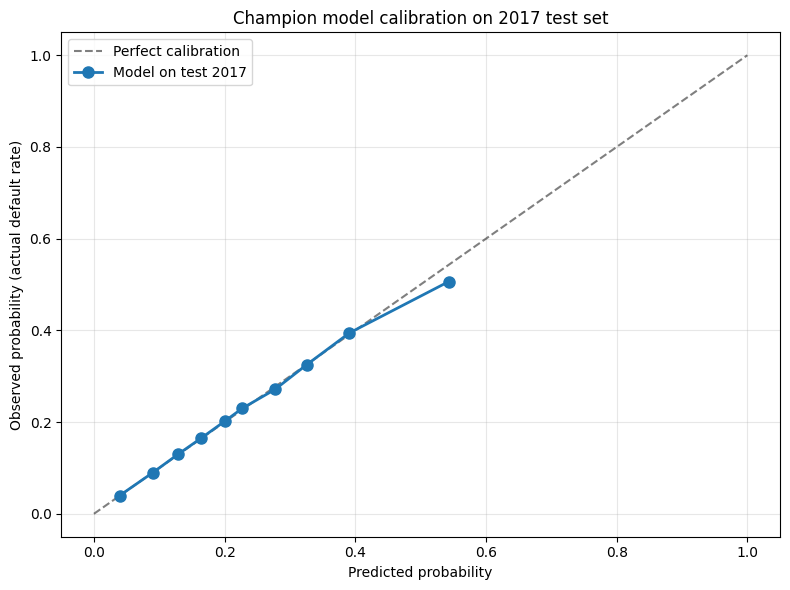


Calibration table (deciles):
 Predicted |   Observed | Difference
--------------------------------------
    0.0393 |     0.0397 |    +0.0004
    0.0898 |     0.0896 |    -0.0003
    0.1285 |     0.1297 |    +0.0011
    0.1637 |     0.1646 |    +0.0009
    0.2000 |     0.2017 |    +0.0017
    0.2273 |     0.2302 |    +0.0030
    0.2771 |     0.2712 |    -0.0059
    0.3258 |     0.3254 |    -0.0005
    0.3909 |     0.3943 |    +0.0034
    0.5430 |     0.5064 |    -0.0366


In [5]:
prob_true, prob_pred = calibration_curve(y_test, calibrated_probs, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', alpha=0.5)
ax.plot(prob_pred, prob_true, 'o-', label='Model on test 2017', linewidth=2, markersize=8)

ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed probability (actual default rate)")
ax.set_title("Champion model calibration on 2017 test set")

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/calibration_test_2017.png", dpi=100, bbox_inches='tight')
plt.show()

print("\nCalibration table (deciles):")
print(f"{'Predicted':>10} | {'Observed':>10} | {'Difference':>10}")
print("-" * 38)
for pred, true in zip(prob_pred, prob_true):
    diff = true - pred
    print(f"{pred:>10.4f} | {true:>10.4f} | {diff:>+10.4f}")

=== THRESHOLD ANALYSIS ON TEST 2017 ===

Threshold from 2016 validation: 0.1592
  Profit on 2017 using this:    $30.86M

2017 optimal threshold (academic only): 0.1700
  Profit on 2017 using this:           $31.30M

Recoverable profit by re-tuning: $0.44M
Pct improvement from re-tuning:  1.4%


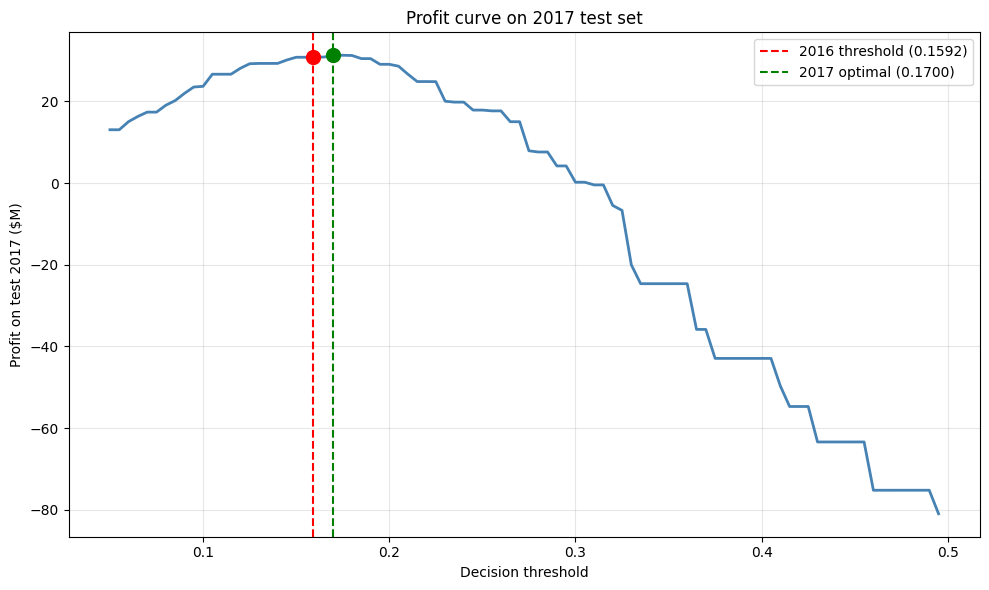

In [6]:
threshold_candidates = np.arange(0.05, 0.50, 0.005)
profits_at_threshold = []

for t in threshold_candidates:
    decisions = (calibrated_probs >= t).astype(int)
    p = calculate_profit(y_test, decisions, loan_amounts_test)
    profits_at_threshold.append(p)

profits_at_threshold = np.array(profits_at_threshold)

# threshold for 2017
best_idx = profits_at_threshold.argmax()
best_threshold_2017 = threshold_candidates[best_idx]
best_profit_2017 = profits_at_threshold[best_idx]

profit_at_2016_threshold = profit_test

print(f"=== THRESHOLD ANALYSIS ON TEST 2017 ===\n")
print(f"Threshold from 2016 validation: {threshold:.4f}")
print(f"  Profit on 2017 using this:    ${profit_at_2016_threshold/1e6:.2f}M")
print(f"\n2017 optimal threshold (academic only): {best_threshold_2017:.4f}")
print(f"  Profit on 2017 using this:           ${best_profit_2017/1e6:.2f}M")
print(f"\nRecoverable profit by re-tuning: ${(best_profit_2017 - profit_at_2016_threshold)/1e6:.2f}M")
print(f"Pct improvement from re-tuning:  {(best_profit_2017 - profit_at_2016_threshold)/profit_at_2016_threshold*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_candidates, profits_at_threshold/1e6, linewidth=2, color='steelblue')
ax.axvline(threshold, color='red', linestyle='--', label=f'2016 threshold ({threshold:.4f})')
ax.axvline(best_threshold_2017, color='green', linestyle='--', label=f'2017 optimal ({best_threshold_2017:.4f})')
ax.scatter([threshold], [profit_at_2016_threshold/1e6], color='red', s=100, zorder=5)
ax.scatter([best_threshold_2017], [best_profit_2017/1e6], color='green', s=100, zorder=5)

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Profit on test 2017 ($M)")
ax.set_title("Profit curve on 2017 test set")

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/threshold_analysis_test_2017.png", dpi=100, bbox_inches='tight')
plt.show()

In [7]:
import json

expected_features = list(preprocessor.feature_names_in_)

val_df = df[df['issue_year'] == 2016].copy()
if val_df['term'].dtype == 'object':
    val_df['term'] = val_df['term'].str.extract(r'(\d+)').astype(int)
if val_df['emp_length'].dtype == 'object':
    emp_length_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
        '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
        '10+ years': 10,
    }
    val_df['emp_length'] = val_df['emp_length'].map(emp_length_map)

y_val = val_df['default'].values
X_val = val_df[expected_features]
loan_amounts_val = val_df['loan_amnt'].values

calibrated_probs_val = calibrator.predict(base_model.predict_proba(preprocessor.transform(X_val))[:, 1])
decisions_val = (calibrated_probs_val >= threshold).astype(int)
profit_val_full = calculate_profit(y_val, decisions_val, loan_amounts_val)

val_auc = roc_auc_score(y_val, calibrated_probs_val)
val_brier = brier_score_loss(y_val, calibrated_probs_val)


print("=== CANONICAL VAL vs TEST COMPARISON (both full datasets) ===\n")
print(f"{'Metric':<25} {'Val 2016 (full)':>20} {'Test 2017 (full)':>20}")
print("-" * 67)
print(f"{'Loans':<25} {len(val_df):>20,} {len(test_df):>20,}")
print(f"{'Default rate':<25} {y_val.mean():>20.4f} {y_test.mean():>20.4f}")
print(f"{'AUC':<25} {val_auc:>20.4f} {auc_test:>20.4f}")
print(f"{'Brier':<25} {val_brier:>20.4f} {brier_test:>20.4f}")
print(f"{'Profit':<25} ${profit_val_full/1e6:>18.2f}M ${profit_test/1e6:>18.2f}M")
print(f"{'Profit per loan':<25} ${profit_val_full/len(val_df):>19.2f} ${profit_test/len(test_df):>19.2f}")
print(f"{'Rejection rate':<25} {decisions_val.mean():>20.4f} {decisions_reject.mean():>20.4f}")
print(f"\nPer-loan profit change: {(profit_test/len(test_df) - profit_val_full/len(val_df))/(profit_val_full/len(val_df))*100:+.1f}%")

test_results = {
    'dataset': '2017 test set (held out, never used during development)',
    'n_loans': len(test_df),
    'actual_default_rate': float(y_test.mean()),
    'total_volume_usd': float(loan_amounts_test.sum()),
    'metrics': {
        'auc': float(auc_test),
        'brier': float(brier_test),
        'profit_at_2016_threshold': float(profit_test),
        'profit_at_2017_optimal_threshold': float(best_profit_2017),
        'recoverable_profit_from_retuning': float(best_profit_2017 - profit_test),
    },
    'thresholds': {
        'deployed_2016_threshold': float(threshold),
        'optimal_2017_threshold': float(best_threshold_2017),
        'gap_to_2017_optimal': float(best_threshold_2017 - threshold),
    },
    'decisions': {
        'rejected_count': int(decisions_reject.sum()),
        'approved_count': int((1 - decisions_reject).sum()),
        'rejection_rate': float(decisions_reject.mean()),
        'fpr_wrongful_rejection': float(fp/(fp+tn)),
        'fnr_missed_default': float(fn/(fn+tp)),
    },
    'comparison_vs_validation_2016': {
        'val_auc': float(val_auc),
        'val_brier': float(val_brier),
        'val_profit': float(profit_val_full),
        'val_profit_per_loan': float(profit_val_full/len(val_df)),
        'test_profit_per_loan': float(profit_test/len(test_df)),
        'auc_change': float(auc_test - val_auc),
        'brier_change': float(brier_test - val_brier),
        'per_loan_profit_change_pct': float((profit_test/len(test_df) - profit_val_full/len(val_df))/(profit_val_full/len(val_df))*100),
    },
}
with open("../reports/test_set_2017_results.json", 'w') as f:
    json.dump(test_results, f, indent=2)

print("\n=== FINAL SUMMARY ===\n")
print(f"Ranking quality: AUC {val_auc:.4f} (val) → {auc_test:.4f} (test), drop of {val_auc - auc_test:.4f}")
print(f"Calibration: Brier {val_brier:.4f} (val) → {brier_test:.4f} (test), change of {brier_test - val_brier:+.4f}")
print("Calibration plot: near-perfect alignment in 9/10 deciles")
print()
print("Threshold robustness:")
print(f"  Deployed (2016): {threshold:.4f}")
print(f"  2017 optimal:    {best_threshold_2017:.4f}")
print(f"  Profit left on the table: ${(best_profit_2017-profit_test)/1e6:.2f}M ({(best_profit_2017-profit_test)/profit_test*100:.1f}%)")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== CANONICAL VAL vs TEST COMPARISON (both full datasets) ===

Metric                         Val 2016 (full)     Test 2017 (full)
-------------------------------------------------------------------
Loans                                  293,095              169,300
Default rate                            0.2328               0.2312
AUC                                     0.7281               0.7188
Brier                                   0.1570               0.1587
Profit                    $             65.57M $             30.86M
Profit per loan           $             223.70 $             182.26
Rejection rate                          0.6260               0.6373

Per-loan profit change: -18.5%

=== FINAL SUMMARY ===

Ranking quality: AUC 0.7281 (val) → 0.7188 (test), drop of 0.0093
Calibration: Brier 0.1570 (val) → 0.1587 (test), change of +0.0017
Calibration plot: near-perfect alignment in 9/10 deciles

Threshold robustness:
  Deployed (2016): 0.1592
  2017 optimal:    0.1700
  Pr